In [ ]:

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt

In [ ]:
# аналогичным образом загружаем данные о пассажирах
ecg = pd.read_csv('data/calm_p.csv')

# неподходящий формат данных приводим к тому, с которым Pandas может работать

df = ecg.set_index('Time').sort_index()

### Скользящее среднее

In [ ]:
df['MA_window_3'] = df['1'].rolling(window=3).mean()
df

In [ ]:
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_3'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

Можно поиграться с размерностью окна

In [ ]:
df['MA_window_6'] = df['1'].rolling(window=600).mean()
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_6'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('s')
plt.show()


Давайте напишем функцию, которая поможет нам понять тенденцию и движения временного ряда. Мы хотим видеть на графике некоторую скользящую статистику, такую как:

M скользящее среднее: невзвешенное среднее предыдущих n данных (также называемое скользящим средним).

Полосы Боллинджера: верхняя полоса в k раз на n -периодное стандартное отклонение выше скользящей средней и нижняя полоса в k раз на стандартное отклонение N ниже.

In [ ]:
'''
Отрисовка скользящего среднего по медиане для ts с 95% доверительным интервалом для стандартного отклонения.
:parameter
  :param ts: датасет
  :param window: кол-во семплов в окне - для скользящих средних
  :param plot_ma: bool - whether plot moving average
  :param plot_intervals: bool - whether plot upper and lower bounds
'''
def plot_ts(ts, plot_ma=True, plot_intervals=True, window=100,
            figsize=(15,5)):
    rolling_mean = ts.rolling(window=window).mean()
    rolling_std = ts.rolling(window=window).std()
    plt.figure(figsize=figsize)
    plt.title(ts.name)
    plt.plot(ts[window:], label='Реальные значения', color="black")
    if plot_ma:
        plt.plot(rolling_mean, 'g', label='MA'+str(window),
                 color="red")
    if plot_intervals:
        lower_bound = rolling_mean - (1.96 * rolling_std)
        upper_bound = rolling_mean + (1.96 * rolling_std)
    plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                     color='lightskyblue', alpha=0.4)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

In [ ]:
plot_ts(df["1"], window=100)
plot_ts(df["1"], window=10)

### ARMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

## Предсказание ряда на основе предыдущих значений

### ARIMA  

Модель авторегрессии скользящего среднего и систематический подход к её построению предназначена для анализа стационарных временных рядов на основе оценки линейной зависимости прогнозируемых значений от исторических.

Для использования модели временной ряд должен быть стационарным, т.е. его среднее и дисперсия должны быть постоянны.

Модель Бокса-Дженкинса предполагает, что временной ряд содержит три составляющие: авторегресионную, интегрированную и скользящее среднее, которые в модели обозначены $p$, $d$ и $q$ соответственно:

* Величина $p$ называется порядком авторегрессии. Она позволяет ответить на вопрос, будет ли очередной элемент ряда близок к значению $X$, если к нему были близки $p$ предыдущих значений.
* Величину $d$ называют порядком интегрирования. Она показывает, насколько элемент ряда близок по значению к $d$ предыдущим значениям, если разность между ними минимальна.

* Параметр $q$— порядок скользящего среднего. Позволяет установить погрешность модели как линейную комбинацию наблюдавшихся ранее значений ошибок.

Авторегрессия — это составляющая модели временного ряда, в которой его прогнозируемое значение может быть выражено в виде линейной комбинации исторических значений этого же ряда и случайной ошибки.

Обычно модель упоминается, как ARIMA$(p,d,q)$, где $p$, $d$ и $q$ — целые неотрицательные числа, характеризующие порядок для частей модели (соответственно авторегрессионной, интегрированной и скользящего среднего).

Для временного ряда $X(t)$ модель может быть записана в виде:

$$(\delta^dX_t)=\sum^p_{t=1}a_t(\delta^dX_{t-1}) + \epsilon_t + \sum^q_{j=1}b_j(\delta^d\epsilon_{t-j})$$

где

* $\delta^d$ — оператор разности порядка $d$ (последовательное взятие $d$ раз разностей первого порядка — сначала от самого ряда, затем от полученных разностей первого порядка, затем от второго порядка и т. д.);
* $a_t$— коэффициенты авторегрессионной части модели, $\epsilon_t$— значения ошибки (полагаются независимыми одинаково распределёнными случайными величинами из нормального распределения с нулевым средним);
* $b_j$ — коэффициенты скользящего среднего.

Модель Бокса-Дженкинса широко применяются при прогнозировании временных рядов. Основная задача при этом заключается в оценке параметров модели. Методология построения ARIMA-модели исследуемого временного ряда включает следующие основные этапы:

* построение пробной модели;
* оценивание параметров модели и проверка адекватности модели;
* использование модели для прогнозирования.

Чтобы построить модель ARMA, мы можем использовать функцию ARIMA (которая будет
объяснена в следующем разделе) в statsmodels.tsa.arima.model и указать
гиперпараметр — order(p, d, q). Когда d = 0, он работает как модель ARMA.

In [ ]:
arma_model = ARIMA(df['1'], order=(5,0,3))
arma_model_fit = arma_model.fit()

In [ ]:
print(arma_model_fit.summary())

In [ ]:
X = df['1'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

In [ ]:
print(len(train))
print(len(test))
print(len(arma_predictions))

In [ ]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

In [ ]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pdf = passengers.set_index('Month').sort_index()

In [ ]:
passengers

In [ ]:
p_arma_model = ARIMA(pdf['Passengers'], order=(5,0,3))
p_arma_model_fit = p_arma_model.fit()

In [ ]:
from IPython.display import clear_output
%matplotlib inline

def live_plot(data_dict, figsize=(7,5), title=''):
    clear_output(wait=True)
    plt.figure(figsize=figsize)
    for label,data in data_dict.items():
        plt.plot(data, label=label)
    plt.title(title)
    plt.grid(True)
    plt.xlabel('epoch')
    plt.legend(loc='center left')
    plt.show()

In [ ]:
series = pdf["Passengers"]
#series = df['1']

size = int(series.shape[0] * 0.5)
train, test = series[:size], series[size:len(series)]
history = [x for x in train.values]
predictions = []

val = {"true":[], "predict":[]}
for t in test.values:
    model = ARIMA(history, order=(5,1,0)).fit()
    output = model.forecast()
    yhat = output[0]
    predictions.append(yhat)
    val["predict"].append(yhat)
    val["true"].append(t)
    history.append(t)
    live_plot(val)

In [ ]:
X = pdf['Passengers'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

In [ ]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('Passengers')
plt.ylabel('Passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### ARIMA

In [ ]:
print(arima_model_fit.summary())

Полезным может быть получение линейного графика остаточных ошибок, что позволяет предположить, что некоторая информация о тенденциях все еще может быть не учтена моделью.

In [ ]:
arima_residuals = pd.DataFrame(arima_model_fit.resid)
arima_residuals.plot()

Осуществляем предсказание

In [ ]:
# forecast предсказывает только следующее значение
output = arima_model_fit.forecast()

In [ ]:
fig = plt.figure(figsize=(20, 9))
plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, len(X) - 1)], test, label='Test data')
plt.plot([i for i in range(size - 1, len(X) - 1)], arima_predictions, label='ARIMA forecast')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

Сравним значения ARMA и ARIMA

In [ ]:
fig = plt.figure(figsize=(20, 9))

delta = []

for i in range(len(arima_predictions)):
    delta.append(arma_predictions[i] - arima_predictions[i])

plt.plot(delta, label='ARIMA(10,2,5) -  ARMA(5,0,3) delta forecast', linewidth=5)
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### Работа с пропусками данных

#### **Задание №1:**


Заполнените пропущенные значения:
* средним и медианой​
* предыдущим и последующим значениями​
* скользящим средним и медианой​

Заполнение предыдущим и последующим значениями​

C:\Users\Nataly\AppData\Local\Temp\ipykernel_15892\2747760591.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_ffill = o_df["Passengers"].fillna(method='ffill')
C:\Users\Nataly\AppData\Local\Temp\ipykernel_15892\2747760591.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_bfill = o_df["Passengers"].fillna(method='bfill')


<Axes: title={'center': 'Последующее значение'}, xlabel='Month'>

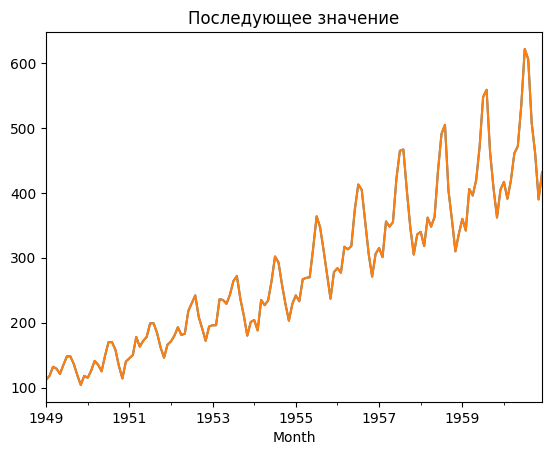

In [16]:
# Предыдущее значение
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
pdf = passengers.set_index('Month').sort_index()

o_df = pdf.copy()  # создаём копию данных о пассажирах
o_df_ffill = o_df["Passengers"].fillna(method='ffill')
o_df_ffill.plot(title="Предыдущее значение")

# Последующее значение
o_df_bfill = o_df["Passengers"].fillna(method='bfill')
o_df_bfill.plot(title="Последующее значение")

Заполнение скользящим средним и медианой​

<Axes: title={'center': 'Скользящая медиана'}, xlabel='Month'>

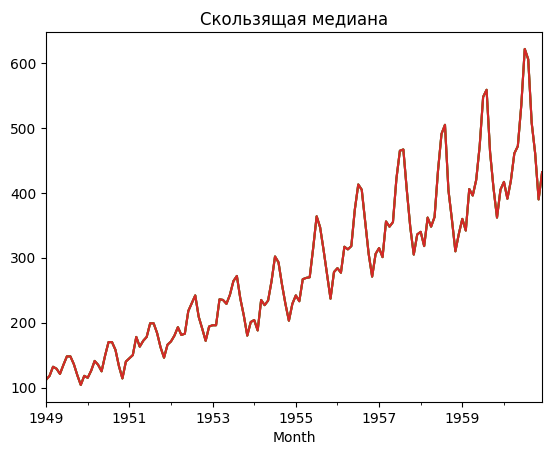

In [17]:
# Заполнение средним
o_df_mean = o_df["Passengers"].fillna(o_df["Passengers"].mean())
o_df_mean.plot(title="Среднее")

# Заполнение медианой
o_df_median = o_df["Passengers"].fillna(o_df["Passengers"].median())
o_df_median.plot(title="Медиана")

# Скользящее среднее (окно 3)
o_df_rolling_mean = o_df["Passengers"].fillna(
    o_df["Passengers"].rolling(window=3, min_periods=1).mean()
)
o_df_rolling_mean.plot(title="Скользящее среднее")

# Скользящая медиана (окно 3)
o_df_rolling_median = o_df["Passengers"].fillna(
    o_df["Passengers"].rolling(window=3, min_periods=1).median()
)
o_df_rolling_median.plot(title="Скользящая медиана")

Интерполяция

### Работа с выбросами

In [ ]:
import seaborn as sns

In [ ]:
pdf["Passengers"].hist(bins=30, color="black")

In [ ]:
ecg["1"].hist(bins=100, color="black",)

In [ ]:
fig = plt.figure(figsize=(14, 9))
 
sns.boxplot(pdf.Passengers).set_title('Пассажиры')

In [ ]:
fig = plt.figure(figsize=(14, 9))
ax = sns.boxplot(ecg["1"])
ax.set_title('ЭКГ')

Давайте напишем функцию для автоматического обнаружения выбросов во временном ряду с использованием алгоритма кластеризации из библиотеки scikit-learn: машина векторов поддержки одного класса, она изучает границы распределения (называемые « support ») и, следовательно, может классифицировать любые точки, лежащие за пределами границы, как выбросы.

In [ ]:
from sklearn import preprocessing, svm

In [ ]:
scaler = preprocessing.StandardScaler()
perc = 0.01

local_df = ecg["1"]

ts_scaled = scaler.fit_transform(local_df.values.reshape(-1,1))
model = svm.OneClassSVM(nu=perc, kernel="rbf", gamma=0.01)
model.fit(ts_scaled)
## dtf output
dtf_outliers =local_df.to_frame(name="ts")
dtf_outliers["index"] = range(len(local_df))
dtf_outliers["outlier"] = model.predict(ts_scaled)
dtf_outliers["outlier"] = dtf_outliers["outlier"].apply(lambda
                                                            x: 1 if x==-1 else 0)
## plot
fig, ax = plt.subplots(figsize=(20, 9))
ax.plot(dtf_outliers["index"], dtf_outliers["ts"],
        color="black")
ax.scatter(x=dtf_outliers[dtf_outliers["outlier"]==1]["index"],
           y=dtf_outliers[dtf_outliers["outlier"]==1]['ts'],
           color='red', linewidths=10)
plt.title(f"Found {sum(dtf_outliers['outlier']==1)} outliers", fontdict={'fontsize': 20})
ax.grid(True)
plt.show()

Но что нам делать с выбросами после обнаружения? Здесь нет оптимальной стратегии: прогнозировать временные ряды проще без точек данных, которые значительно отличаются от других наблюдений, но удаление этих точек может глубоко изменить распределение данных. Если вы решили исключить выбросы, наиболее удобный способ их удаления - интерполяция.

In [ ]:
outliers_idx = dtf_outliers[dtf_outliers["outlier"]==1].index

ts_clean = local_df.copy()
ts_clean.loc[outliers_idx] = np.nan
ts_clean = ts_clean.interpolate(method="linear")
ax = local_df.plot(figsize=(20, 9), color="red", alpha=0.5,
             title="Remove outliers", label="original", legend=True, linewidth=2)
ts_clean.plot(ax=ax, grid=True, color="black",
              label="interpolated", legend=True)
plt.legend(fontsize="20")
plt.show()

# Задание №2: Анализ нестационарного ряда и прогнозирование с ARIMA

## Описание
У вас есть временной ряд продаж онлайн-магазина за 200 дней. Ряд нестационарный (имеет тренд и случайный шум).

**Ваша задача:**
* Загрузить и визуализировать ряд
* Проверить стационарность с помощью ADF-теста
* Применить дифференцирование и убедиться, что ряд стал стационарным
* Выбрать оптимальные параметры ARIMA(p,d,q)
* Сделать walk-forward прогноз на тестовом наборе
* Оценить качество прогноза (MAE, RMSE)


In [19]:
import numpy as np
import pandas as pd
np.random.seed(42)

# Генерируем нестационарный ряд
n = 200
trend = np.linspace(50, 250, n)  # Линейный тренд от 50 к 250
noise = np.random.normal(0, 15, n)  # Шум
random_walk = np.cumsum(np.random.normal(0, 5, n))  # Random walk

sales = trend + random_walk + noise

df = pd.DataFrame({'day': np.arange(1, n+1),'sales': sales})
df.set_index('day', inplace=True)
df.head(10)

,sales
day,
1,59.239649
2,53.523920
3,71.733494
4,91.137649
5,58.896579
6,55.212725
7,85.993173
8,77.390457
9,62.417084


2: Визуализация ряда

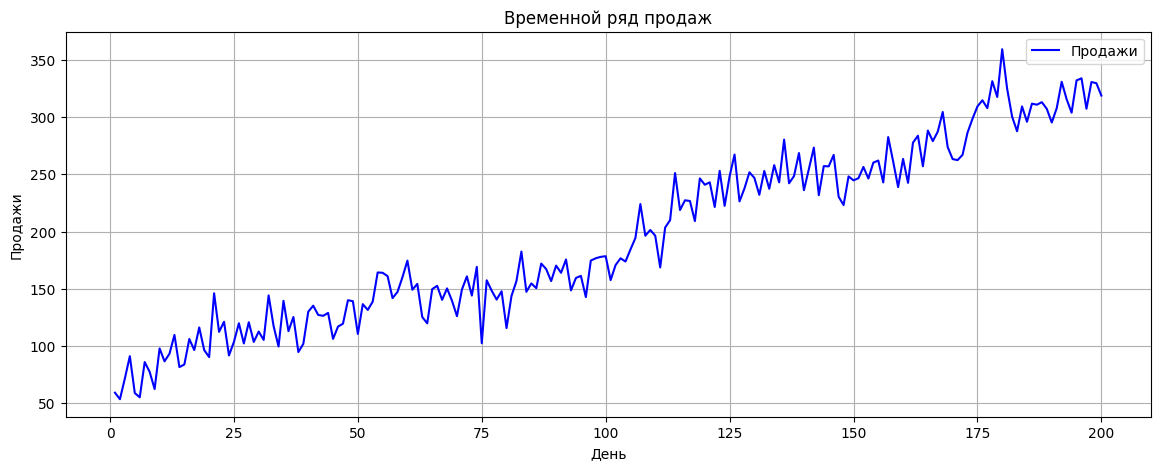

In [20]:
# Постройте график исходного временного ряда
# Используйте figsize=(14, 5), добавьте label, title, xlabel, ylabel
# Ваш код
plt.figure(figsize=(14, 5))
plt.plot(df['sales'], label='Продажи', color='blue')
plt.title('Временной ряд продаж')
plt.xlabel('День')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.show()

3: Проверка стационарности (ADF-тест)

**Тест Дики-Фуллера:**
- H0 (нулевая гипотеза): ряд имеет единичный корень (нестационарен)
- Если p-value < 0.05, мы отклоняем H0 → ряд стационарен
- Если p-value > 0.05, ряд нестационарен

In [23]:
# Ваш код
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f'ADF-тест для {title}:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    if result[1] < 0.05:
        print('Ряд стационарен (отвергаем гипотезу H0)')
    else:
        print('Ряд нестационарен (принимаем гипотезу H0)')

check_stationarity(df['sales'], 'Исходный ряд')

ADF-тест для Исходный ряд:
ADF Statistic: -0.5925
p-value: 0.8727
Critical Values:
	1%: -3.465
	5%: -2.877
	10%: -2.575
Ряд нестационарен (принимаем гипотезу H0)


4: Дифференцирование

Возьмём первую разность: Δy_t = y_t - y_(t-1)

In [24]:
#  Применить первое дифференцирование (d=1)
# Используйте df['sales'].diff() для получения разностей
# Ваш код
df['sales_diff'] = df['sales'].diff()
df_diff = df['sales_diff'].dropna()

5: Проверка стационарности разности

In [25]:
# Используйте функцию check_stationarity()
# Ваш код
check_stationarity(df_diff, 'Первая разность')

ADF-тест для Первая разность:
ADF Statistic: -10.2440
p-value: 0.0000
Critical Values:
	1%: -3.465
	5%: -2.877
	10%: -2.575
Ряд стационарен (отвергаем гипотезу H0)


6: Выбор параметров ARIMA

Поскольку мы применили d=1, нам нужно выбрать p и q.
Совет: для т.ч. ряда часто подходят небольшие значения, например p=1-5, q=0-3

In [26]:
# Вариант 1 : начните с ARIMA(1,1,1)
# Вариант 2 : переберите несколько вариантов и выберите по AIC
# Выбирайте как душе угодно) 

# Жду ваш код
from statsmodels.tsa.arima.model import ARIMA

best_aic = np.inf
best_order = None
best_model = None

for p in range(0, 5):
    for q in range(0, 4):
        try:
            model = ARIMA(df['sales'], order=(p, 1, q))
            model_fit = model.fit()
            aic = model_fit.aic
            if aic < best_aic:
                best_aic = aic
                best_order = (p, 1, q)
                best_model = model_fit
        except:
            continue

print(f'Лучшая модель ARIMA{best_order} с AIC = {best_aic:.2f}')
print(best_model.summary())

c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nataly\AppData\Local\Programs\Python\Python312

Лучшая модель ARIMA(2, 1, 3) с AIC = 1702.25
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  200
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -845.123
Date:                Fri, 27 Mar 2026   AIC                           1702.246
Time:                        23:53:15   BIC                           1722.006
Sample:                             0   HQIC                          1710.243
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8602      0.044    -42.745      0.000      -1.945      -1.775
ar.L2         -0.9361      0.044    -21.488      0.000      -1.021      -0.851
ma.L1  

7: Walk-Forward Validation и прогнозирование

In [27]:
# Ваш код
train_size = int(len(df) * 0.8)
train, test = df['sales'][:train_size], df['sales'][train_size:]

history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()
    forecast = model_fit.forecast()[0]
    predictions.append(forecast)
    history.append(test.iloc[t])

predictions = pd.Series(predictions, index=test.index)

c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

8: Визуализация + метрики

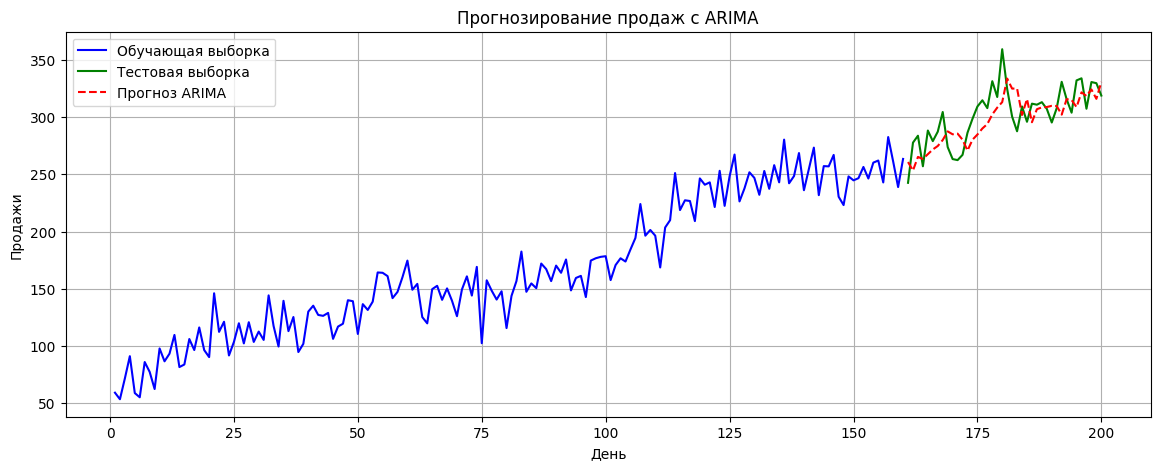

MAE = 16.12
RMSE = 18.79


In [28]:
# Ваш код
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.figure(figsize=(14, 5))
plt.plot(train, label='Обучающая выборка', color='blue')
plt.plot(test, label='Тестовая выборка', color='green')
plt.plot(predictions, label='Прогноз ARIMA', color='red', linestyle='--')
plt.title('Прогнозирование продаж с ARIMA')
plt.xlabel('День')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.show()

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'MAE = {mae:.2f}')
print(f'RMSE = {rmse:.2f}')